On a trip to Copenhagen, I biked in a city for the first time in a decade. It was delightful and liberating, and it made sense that the majority of Copenhagen residents primarily commuted by bike. Returning home to Chicago, I bought a bike and quickly felt the difference that bike infrastructure and culture makes.

In Copenhagen, bike safety and bike theft were basically solved problems. Extensive infrastructure made routes everywhere safe to bike and from the number of unlocked bikes, it was clear that bike theft wasn't an issue. Back in Chicago, I was sharing lanes with cars going 40 mph and despite extensive locking and uglying up my bike, I still never know if my bike will still be there. Over time I've learned safer, more comfortable routes, and Chicago keeps building out new infrastructure, but the gap between those two experiences stuck with me. So I built a tool to help find the safer routes and find secure parking areas.

I wanted to gain a richer understanding of how routing algorithms work, and I wanted to find routes that optimize for cyclist safety instead of speed or distance. The result is a platform that scores every road segment in the Chicago area for danger — using crash data, bike infrastructure, speed limits, and road type — and routes you through the safest path, not the shortest one. It also maps bike thefts and parking infrastructure so you can figure out where it's safe to lock up.

You can try it at [bike-map.dev.missinglastmile.net](https://bike-map.dev.missinglastmile.net/).

| ![elt dags in airflow](imgs/bike_map__palmer_park_to_wrigley.png) | ![querying through superset](imgs/google_maps__palmer_park_to_wrigley.png) |
|:--:|:--:|
| Bike-Maps Safety-Optimized Route | Google Maps Routes |

## What does "safe" mean for a road segment?

This is the interesting question at the heart of the project. Google Maps and other routing tools optimize for time or distance. Some have basic bike modes that prefer bike lanes when they exist. But none of them let you define what "safe" means to you, or plug in local crash data to inform the route.

I wanted to combine several factors:

- **Crash history**: where have cyclists actually been hit? More recent crashes weigh more heavily (largely as I don't know when infrastructure was created and want to downweight old crashes in case new infrastructure has been added).
- **Bike infrastructure**: is there a protected lane, a painted bike lane, a sharrow, or nothing at all? How close can cars get to you?
- **Speed limits**: a 25 mph residential street is a very different environment from a 40 mph arterial.
- **Road type**: a dedicated bike path is inherently different from a four-lane road, even before you look at infrastructure or crash data.
- **Traffic control devices**: Intersections are the most dangerous place to ride and that's somewhat mitigated by a traffic control device (e.g. a stop sigh, traffic light, etc).

Each road segment gets a cost that estimates the risk of riding down that segment, and the routing algorithm finds the path with the lowest total score — the safest route, not the shortest one.




<!-- TODO: Consider a screenshot showing the crash data layer or bike theft layer on the map, to visually convey "the risk isn't evenly distributed" -->

## How routing algorithms work (briefly)

The basic idea is simpler than I expected. A road network is a graph — intersections are nodes, road segments are edges. Each edge has a cost. A routing algorithm finds the path from A to B with the lowest total cost.

In Google Maps, that cost is usually travel time. In my case, it's a safety score. The algorithm itself (A*, a classic pathfinding algorithm) doesn't care what the cost represents — it just finds the cheapest path. The interesting work is in defining what "cost" means.

So the data engineering challenge was: take raw OpenStreetMap road data (which includes speed limits, traffic control device info, bike infrastructure, and more) and crash reports from the city and turn all of that into a estimate of the cost/risk of biking on each road segment.

## What I actually built

The platform has a few pieces:

- **Data collection**: I pull road network data from OpenStreetMap, crash data and bike infrastructure data from the City of Chicago's open data portal, and bike parking fixture locations.
- **Transformation**: I use dbt (a SQL-based transformation tool) to clean, join, and score all of that data. This is where the safety weighting happens — each segment gets scored based on the factors above.
- **Graph export**: the scored road network gets exported as a graph file and uploaded to S3.
- **Routing API**: an AWS Lambda function loads the graph into memory and runs A* pathfinding when someone requests a route. It costs about $1.50/month to operate.
- **Frontend**: a MapLibre-based web map that lets you explore crash data, theft data, and bike parking, and request safety-weighted routes between any two points.

<!-- TODO: Optional — a simple architecture diagram. Even a hand-drawn one would work. But don't force it if it feels like too much for this post. -->

## One thing that surprised me

A sharrow — the painted bike symbol on the road that signals a "shared lane" — barely reduces a segment's safety score compared to having no bike infrastructure at all. A protected bike lane, on the other hand, cuts the danger score dramatically. I knew this intuitively as a cyclist, but seeing it quantified was striking.

This means my router will happily send you a few blocks out of your way to keep you on a street with a protected lane, rather than routing you down a sharrow'd arterial road. That's a tradeoff Google Maps would never make, because it's optimizing for time. My router is optimizing for "you don't get hit by a car."

<!-- TODO: This would be a great place for a side-by-side screenshot — a route your app suggests vs the most direct route, showing where and why they diverge. If that's hard to produce, skip it. -->

## The theft and parking problem

The routing gets the most attention, but the data layers might be more useful day-to-day. The app shows where bike thefts are concentrated and where the city's bike parking fixtures are — racks, corrals, etc. Before I ride somewhere I haven't been, I check whether there's a reasonable place to lock up. That's the Copenhagen problem I still haven't fully solved in Chicago, but at least now I can make informed decisions about it.

## Try it out

The app is live at [bike-map.dev.missinglastmile.net](https://bike-map.dev.missinglastmile.net/). Pick two points in Chicago and see what route it suggests. Toggle the crash and theft layers to see how risk is distributed across the city.

I'd genuinely love feedback — especially from people who ride in Chicago. Do the routes match your experience? Are there roads the app suggests that you'd avoid, or roads it avoids that you think are fine? That kind of local knowledge is exactly what helps me tune the model.

If you're interested in the technical details — the dbt models, the Lambda deployment, or how I penalize left turns — I'll be writing more about specific pieces of the platform in future posts.


# Why Jupyterlab

Jupyter notebooks are great for developing data products, whether it's data analysis, data pipelines, or (classical) ML models. The format enables an interactive, iterative workflow where you can incrementally execute snippets of code and immediately seeing results inline. This makes it very easy to incrementally build your analyis and/or data pipeline and then develop that code into reusable and importable functions or classes.

In this post, I'll show:
* an example of this Jupyter-enabled workflow (both the EDA workflow and the tooling development workflow), and
* how I set up `jupyterlab` (including my solutions to `jupyterlab`'s few annoying quirks)

# Example Workflow

I'll break this down into two parts, the EDA (Exploratory Data Analysis) workflow, and then the Development workflow (which will build upon the EDA workflow).

## Exploratory Data Analysis workflow

Thanks to python's robust data science/analysis/engineering ecosystem, you can load a dataset into memory in one line of code and then iteratvely explore loaded datasets, as shown in the **cells** below.

In [1]:
#| code-fold: true
#| code-summary: Formatting and Imports
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 150

In [2]:
#| code-fold: show
#| code-summary: Loading data
chicago_boundary = gpd.read_file("https://data.cityofchicago.org/api/geospatial/qqq8-j68g?method=export&format=GeoJSON")
chicago_park_events = gpd.read_file("https://data.cityofchicago.org/api/geospatial/tn7v-6rnw?method=export&format=GeoJSON")

print(chicago_park_events.shape)
display(chicago_park_events.head(2))

(7597, 28)


,start_date,latitude,zip,description,registration_date,location_notes,restrictions,activity_type,age_range,season,longitude,registration_link,activity_id,end_date,image_link,location_facility,address,category,information_link,title,event_cancelled,type,movie_title,movie_rating,zone,date_notes,fee,geometry
0,2026-01-07 07:00:00,None,None,"January 7, 2026 to March 4, 2026",2025-12-10 15:00:00,None,None,Open,All Ages,None,None,None,567134,2026-03-04 08:00:00,None,None,None,Sports - Skating,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/567134,Ice Skating - Freestyle Ice (Main Rink) at McFetridge,None,Program,None,None,None,"From January 7, 2026 to March 4, 2026 Each Wednesday from 7am to 8am",72,None
1,2026-01-05 18:50:00,None,None,"January 5, 2026 to February 23, 2026",2025-12-10 15:00:00,None,None,Instruction,All Ages,None,None,None,567122,2026-02-23 19:30:00,None,None,None,Sports - Skating,http://apm.activecommunities.com/chicagoparkdistrict/Activity_Search/567122,Ice Skating - Freestyle 5 at McFetridge,None,Program,None,None,None,"From January 5, 2026 to February 23, 2026 Each Monday from 6:50pm to 7:30pm",127,None


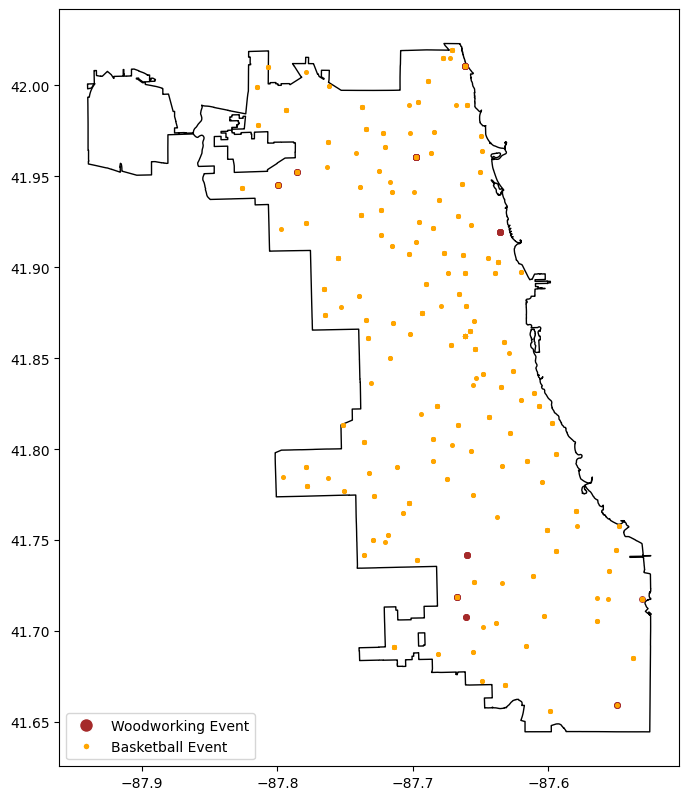

In [3]:
#| code-fold: show
#| code-summary: Exploring data
woodworking_events = chicago_park_events.loc[chicago_park_events["category"] == "Woodworking"]
basketball_events = chicago_park_events.loc[chicago_park_events["category"] == "Sports - Basketball"]

fig, ax = plt.subplots(figsize=(8,10))
ax = chicago_boundary.plot(facecolor="none", ax=ax)
ax = woodworking_events.plot(markersize=15, ax=ax, color="brown")
ax = basketball_events.plot(markersize=7, ax=ax, color="orange")
legend_elements = [
    Line2D([0], [0], marker="o", color='w', markerfacecolor="brown", markersize=10, label="Woodworking Event"),
    Line2D([0], [0], marker=".", color='w', markerfacecolor="orange", markersize=10, label="Basketball Event"),
]
_ = ax.legend(handles=legend_elements, loc="lower left")

In [9]:
#| code-fold: show
#| code-summary: Making code importable
import sys
from pathlib import Path

module_dir = Path(".").resolve()
print(f"Directory we're adding to the python path (so we can import from it):\n  {module_dir}")
sys.path.append(str(module_dir))

Directory we're adding to the python path (so we can import from it):
  /home/matt/projects/blogs/quarto_blog/posts/020_uv_jupyterlab_setup


Jupyter notebooks default to only executing imports once, so changes made to code in a local `.py` file won't be accessible in your notebook unless you configure your notebook to automatically reload changes.